In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import scipy
import matplotlib as mpl
from scipy.special import gamma

STARTING_RANGE_PARAMETER = 0.01 # In [fm^-2]
ENDING_RANGE_PARAMETER = 250
REDUCED_MASS = 935 * (4 / 5) # In [Mev / c^2], need to update value and units (10/11 A in MeV)
SUM_LIMIT = 80 # Determines the number of gaussians we expand our wave function to

V_LS = 11.71 # In MeV
DIFFUSIVITY = 0.6 # Diffusivity, may want to check the vaidity of this paticular number
r_0 = 1.2 # In fm, may want to chose a better value for small nuclei
A_C = 4 # The number of nucleons in the core

CENTRAL_POTENTIAL_PARAMETERS = [1 / ((2.30)**2)]

CENTRAL_MIXING_COEFFICIENTS = [1]

SPIN_ORBIT_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

SPIN_ORBIT_MIXING_COEFFICIENTS = [1]

In [41]:
def single_particle_overlap(range_parameter_i, range_parameter_j):
    return ((2 * range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**(1.5)

def single_particle_potential_element(range_parameter_i, range_parameter_j, central_potential_mixing_coefficient,
                             central_potential_param):
    V_0 = -47.32 * 2
    term_1 = 2 / (range_parameter_i * range_parameter_j)
    term_2 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + central_potential_param)
    return V_0 * (term_1 * term_2)**(1.5)

def single_particle_kinetic_element(range_parameter_i, range_parameter_j, μ=REDUCED_MASS):
    term_1 = range_parameter_i**2 + range_parameter_j**2
    return (197**2 / (2 * μ)) * 6 * single_particle_overlap(range_parameter_i, range_parameter_j) / term_1

def super_symmetric_potential_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                      central_potential_param, k_value, μ=REDUCED_MASS):
    """
    Supersymmetric potential that removes the bound 1s groundstate
    associated with the neutrons in the He-4 core.
    """
    core_neutron_potential =  potential_matrix_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                                       central_potential_param)
    alpha_k = 1 / next_range_parameter(k_value)**0.5
    super_symmetry_term = 2 * (197**2 / μ) * alpha_k**(-2) *  overlap_matrix_element(range_param_i, range_param_j)
    return core_neutron_potential + super_symmetry_term

In [42]:
def matrix_generation(central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])

            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)

    return h_matrix, n_matrix


def susy_correction_mat_gen(tot_ang_momentum, orb_ang_momentum, k_value, theta, central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size), dtype=np.complex_)
    n_matrix = np.zeros(shape=(size, size), dtype=np.complex_)

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)
            # ((2 * 10**(np.abs(i - j))) / (1 + 10**(2 * np.abs(i - j))))**(1.5 + orb_ang_momentum)
            # n_matrix[j, i] = n_matrix[i, j]
            # j += 1

    return h_matrix, n_matrix


def next_range_parameter(i, starting_range_parameter=STARTING_RANGE_PARAMETER, ending_range_parameter=ENDING_RANGE_PARAMETER,
                         sum_limit=SUM_LIMIT):
    """
    Finds the next range parameter given the previous and initial range parameters.
    Currently using a simple geometric series to determine range parameters.
    Chose geometric basis parameters $\alpha_i = \alpha_1a^{i-1}$ with initial parameters $\alpha_1 = 0.01, a=2$

    Parameters
    ----------
    i : int detailing the iteration number

    Returns
    -------
    new_range_parameter: float

    """
    geometric_progression_number = (ending_range_parameter / starting_range_parameter)**(1 / (sum_limit - 1))
    new_range_parameter = starting_range_parameter * geometric_progression_number**(i)
    #new_range_parameter = 1 / new_range_parameter**2

    return new_range_parameter

#theta = 5 * np.pi / 36 
#s_h_matrix, s_n_matrix = matrix_generation(0.5, 0, theta)
#p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, theta)
#p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, theta)
#d_five_half_h_matrix, d_five_half_n_matrix = matrix_generation(2.5, 2, theta)

In [43]:
s_h_matrix, s_n_matrix = matrix_generation()
s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(s_h_matrix, s_n_matrix)
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(s_n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is", s_overlap_matrix_condition_number)

s0_eigenvector = np.asmatrix(s_eigenvectors[:, 0])
s1_eigenvector = np.asmatrix(s_eigenvectors[:, 1])
print("The S state eigenvalues are", s_eigenvalues)
print("The S0 eigenvector is", s0_eigenvector)
#print(s_eigenvalues[0])

The s 1/2 overlap matrix condition number is 1456220863389904.2
The S state eigenvalues are [-3.97191215e+01 -2.92477531e-01  4.45637973e-04  1.80906809e-03
  4.17245047e-03  7.68144041e-03  1.25583749e-02  1.91211111e-02
  2.78082829e-02  3.92123837e-02  5.41228838e-02  7.35824083e-02
  9.89597411e-02  1.32044553e-01  1.75171772e-01  2.31388291e-01
  3.04678830e-01  4.00270486e-01  5.25040822e-01  6.88047882e-01
  9.01183832e-01  1.18000853e+00  1.54488392e+00  2.02251924e+00
  2.64805072e+00  3.46790330e+00  4.54376784e+00  5.95776919e+00
  7.81877098e+00  1.02702250e+01  1.35003218e+01  1.77550709e+01
  2.33547580e+01  3.07155497e+01  4.03786072e+01  5.30474427e+01
  6.96368731e+01  9.13402509e+01  1.19715526e+02  1.56783547e+02
  2.05142517e+02  2.68126146e+02  3.50041037e+02  4.56493989e+02
  5.94795660e+02  7.74453464e+02  1.00779677e+03  1.31077157e+03
  1.70394334e+03  2.21379454e+03  2.87447610e+03  3.73016021e+03
  4.83803757e+03  6.27197441e+03  8.12704803e+03  1.05255761e+0

Ground state wavefunction has overlap 1.0000000000000004 with itself


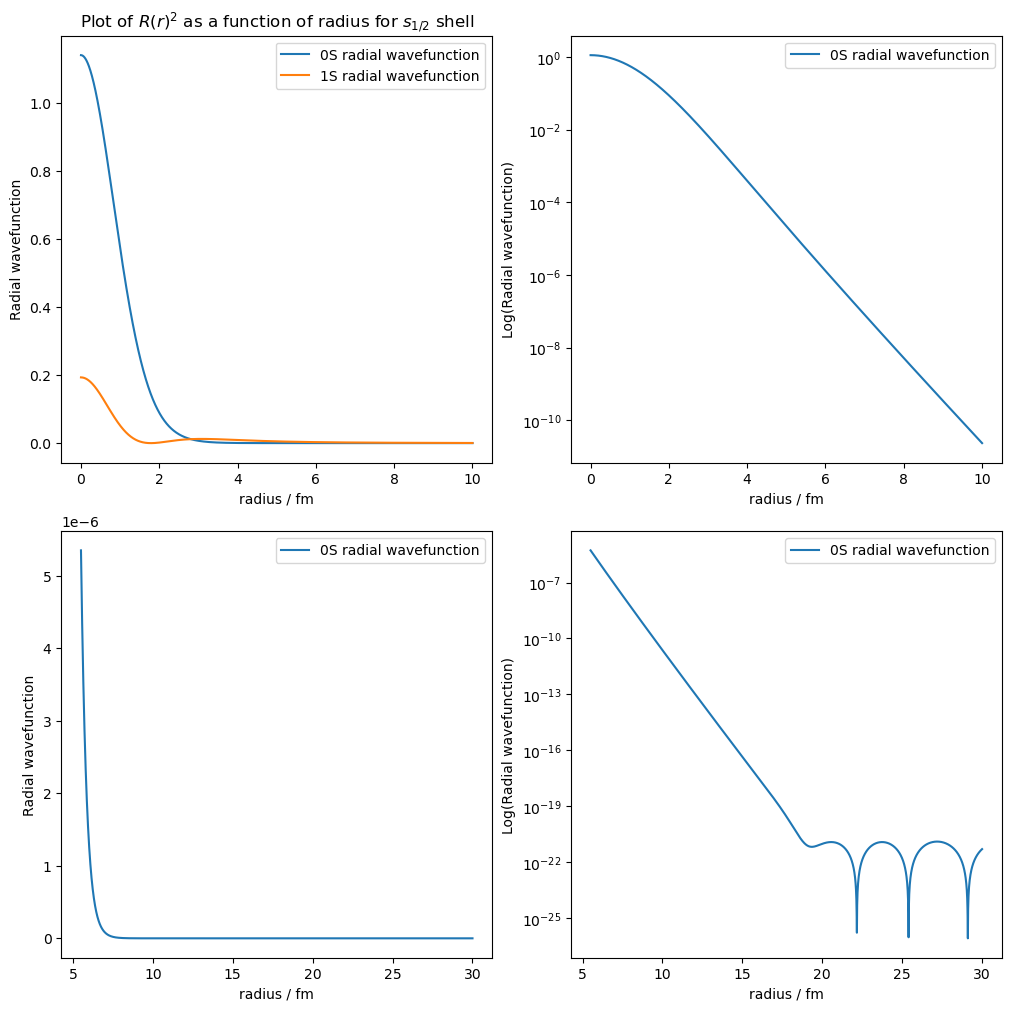

In [44]:
def wavefunction_overlap(orb_ang_momentum_i, orb_ang_momentum_j, i_mixing_coefficients, j_mixing_coefficients, overlap_matrix=None, size=SUM_LIMIT):
    try:
        _ = overlap_matrix.shape
        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
    except AttributeError:
        overlap_matrix = np.zeros(shape=(size, size))

        for i in range(size):
            i_range_parameter = next_range_parameter(i)
            for j in range(size):
                j_range_parameter = next_range_parameter(j)
                overlap_matrix[i, j] = different_l_overlap_matrix_element(orb_ang_momentum_i, orb_ang_momentum_j, i_range_parameter, j_range_parameter)

        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
print(f'Ground state wavefunction has overlap {wavefunction_overlap(0, 0, s0_eigenvector, s0_eigenvector, overlap_matrix=s_n_matrix)} with itself')

def radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number, sum_limit=SUM_LIMIT):
    """
    Defines a numerical method of finding the reduced radial wavefunction as a sum of our gaussians.
    """
    def gaussian_wavefunction(radius, range_parameter, orb_ang_momentum):
        normalisation = (2**(-2.5 - orb_ang_momentum) * (range_parameter)**(3 + 2 * orb_ang_momentum) * gamma(1.5 + orb_ang_momentum))**(-0.5)
        return normalisation * radius**(orb_ang_momentum) * np.exp(- (radius / range_parameter)**2)
    wavefunction_vals = np.zeros(shape=(len(x_values),))

    for i in range(len(x_values)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            wavefunction_vals[i] += (wavefunction_eigenvector[0, j] * gaussian_wavefunction(x_values[i], 
                range_parameter, orbital_quantum_number))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

x_values = np.linspace(0, 10, 3000)
x_values_2 = np.linspace(5.5, 30, 3000)

fig = plt.figure(figsize=(10, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[1,0])
ax_4 = fig.add_subplot(spec[1,1])
ax_1.set_title(r'Plot of $R(r)^{2}$ as a function of radius for $s_{1/2}$ shell')
ax_1.set_xlabel('radius / fm')
ax_1.set_ylabel('Radial wavefunction')
ax_1.plot(x_values, radial_wavefunction(x_values, s0_eigenvector, 0), label="0S radial wavefunction")
ax_1.plot(x_values, radial_wavefunction(x_values, s1_eigenvector, 0), label="1S radial wavefunction")
ax_1.legend()

ax_2.set_xlabel('radius / fm')
ax_2.set_ylabel('Log(Radial wavefunction)')
ax_2.semilogy(x_values, radial_wavefunction(x_values, s0_eigenvector, 0), label="0S radial wavefunction")
ax_2.legend()

ax_3.set_xlabel('radius / fm')
ax_3.set_ylabel('Radial wavefunction')
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_3.legend()

ax_4.set_xlabel('radius / fm')
ax_4.set_ylabel('Log(Radial wavefunction)')
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_4.legend()



While a lengthy output, the effect of the shift is clearly evident, as omly the original ground state is effected.
We now want to move to the supersymmetric potential. We start by plotting the supersymmetric potnetial to get a feel for its behaviour.

In [45]:
def gauss_normalisation(range_param):
    return (2 / (np.pi * (range_param**2)))**(0.75)

def gauss_wavefunc(radius, range_param):
    return gauss_normalisation(range_param) * np.exp(- radius**2 / range_param**2)

def gauss_wavefunc_first_derivitave(radius, range_param):
    return - (2 * radius) / (range_param**2) * gauss_wavefunc(radius, range_param)

def gauss_wavefunc_second_derivitave(radius, range_param):
    return (2 / range_param**2) * (((2 * radius**2) / range_param**2) - 1) * gauss_wavefunc(radius, range_param)

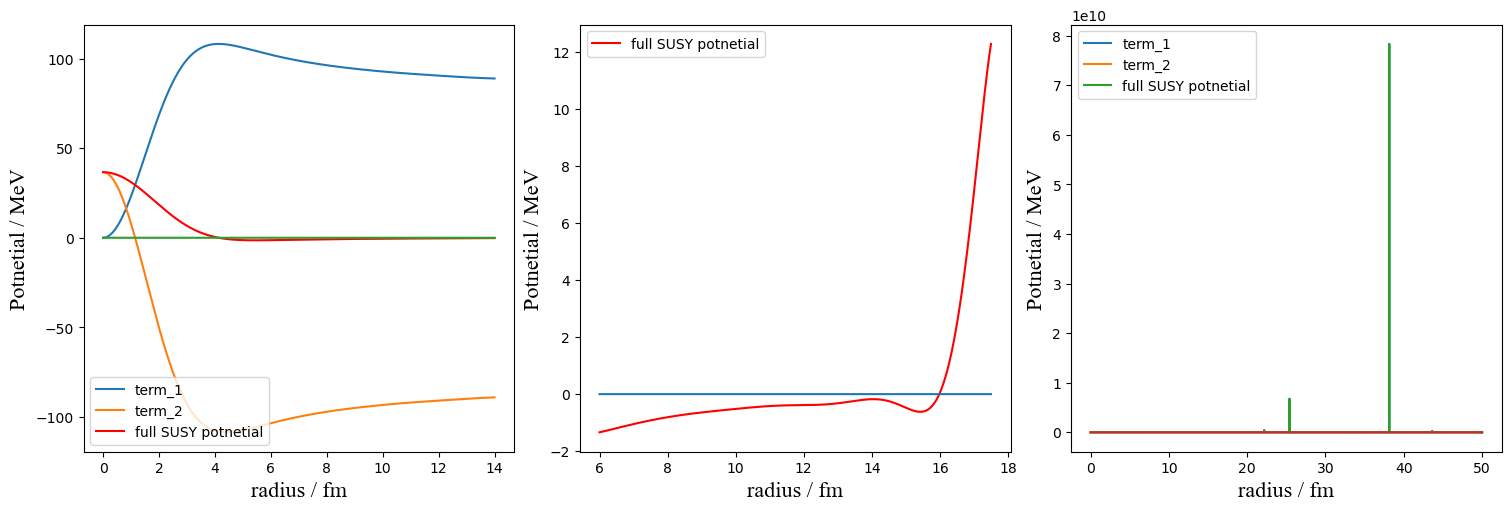

In [46]:
def susy_potential_plot_function(radius, mixing_coeffs, size=SUM_LIMIT):
    susy_term_1_vals = np.zeros(shape=(len(radius),))
    susy_term_2_vals = np.zeros(shape=(len(radius),))

    mixing_coeffs = np.real(mixing_coeffs)
    for i in enumerate(radius):
        term_A = 0
        term_B = 0
        term_C = 0
        for k in enumerate(mixing_coeffs):
            range_parameter = next_range_parameter(k[0])
            term_A += gauss_wavefunc(i[1], range_parameter) * mixing_coeffs[k[0]]
            term_B += gauss_wavefunc_first_derivitave(i[1], range_parameter) * mixing_coeffs[k[0]]
            term_C += gauss_wavefunc_second_derivitave(i[1], range_parameter) * mixing_coeffs[k[0]]
        susy_term_1_vals[i[0]] = (197**2 / REDUCED_MASS) * (term_B / term_A)**2
        susy_term_2_vals[i[0]] = -(197**2 / REDUCED_MASS) * (term_C / term_A)

    return susy_term_1_vals, susy_term_2_vals


r_vals = np.linspace(0, 14, 10000)
r_vals_2 = np.linspace(6, 17.5, 10000)
r_vals_3 = np.linspace(0, 50, 10000)
susy_term_1_vals, susy_term_2_vals = susy_potential_plot_function(r_vals, s_eigenvectors[:, 0])
susy_term_1_vals_2, susy_term_2_vals_2 = susy_potential_plot_function(r_vals_2, s_eigenvectors[:, 0])
susy_term_1_vals_3, susy_term_2_vals_3 = susy_potential_plot_function(r_vals_3, s_eigenvectors[:, 0])

fitting_data = np.column_stack((r_vals, susy_term_1_vals + susy_term_2_vals))
np.savetxt("susy_potential_data.csv", fitting_data, delimiter = ",")


fig = plt.figure(figsize=(15, 5), layout='constrained')
spec = fig.add_gridspec(ncols=3, nrows=1)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[0,2])

ax_1.plot(r_vals, susy_term_1_vals, label='term_1')
ax_1.plot(r_vals, susy_term_2_vals, label='term_2')
ax_1.plot(r_vals, susy_term_1_vals + susy_term_2_vals, label='full SUSY potnetial', color='r')
ax_1.legend()
ax_1.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_1.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_1.plot(r_vals, r_vals*0)

#ax_2.plot(r_vals_2, susy_term_1_vals_2, label='term_1')
#ax_2.plot(r_vals_2, susy_term_2_vals_2, label='term_2')
ax_2.plot(r_vals_2, susy_term_1_vals_2 + susy_term_2_vals_2, label='full SUSY potnetial', color='r')
ax_2.legend()
ax_2.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_2.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_2.plot(r_vals_2, r_vals_2*0)

ax_3.plot(r_vals_3, susy_term_1_vals_3, label='term_1')
ax_3.plot(r_vals_3, susy_term_2_vals_3, label='term_2')
ax_3.plot(r_vals_3, susy_term_1_vals_3 + susy_term_2_vals_3, label='full SUSY potnetial')
ax_3.legend()
ax_3.set_xlabel('radius / fm', fontsize=16, fontname='Times New Roman')
ax_3.set_ylabel('Potnetial / MeV', fontsize=16, fontname='Times New Roman')
ax_3.plot(r_vals_3, r_vals_2*0)



In [51]:
r_vals = np.linspace(0, 14, 2000)
r_vals_2 = np.linspace(0, 20, 2000)
r_vals_3 = np.linspace(0, 30, 2000)
r_vals_4 = np.linspace(1, 20, 2000)
susy_term_1_vals, susy_term_2_vals = susy_potential_plot_function(r_vals, s_eigenvectors[:, 0])
susy_term_1_vals_2, susy_term_2_vals_2 = susy_potential_plot_function(r_vals_2, s_eigenvectors[:, 0])
susy_term_1_vals_3, susy_term_2_vals_3 = susy_potential_plot_function(r_vals_3, s_eigenvectors[:, 0])

max difference between susy potential and gaussian estimate = 0.14001701951769124 MeV, at r = 0


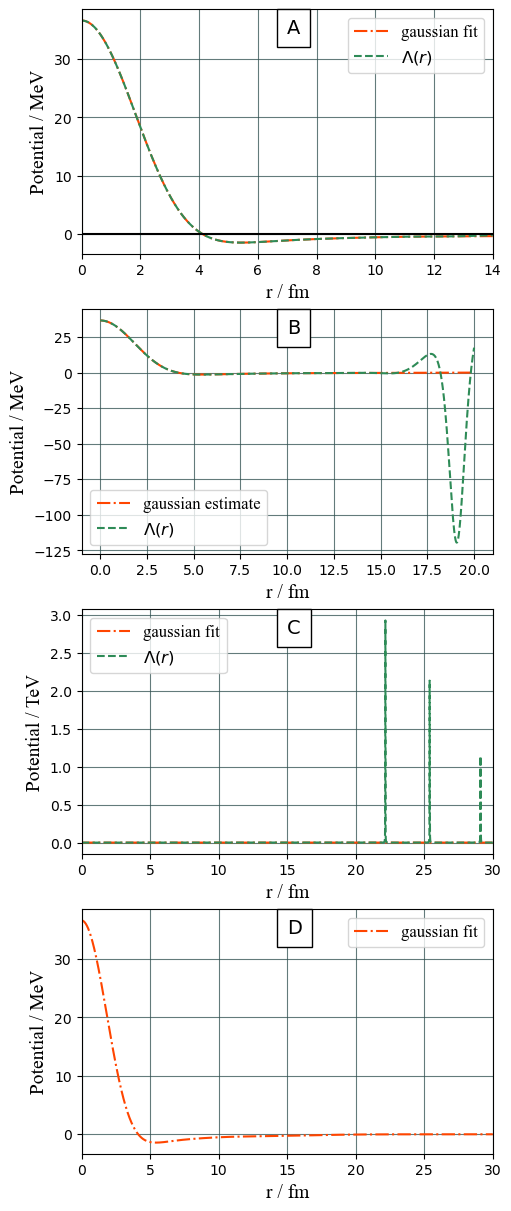

In [54]:
NUM_SUSY_GAUSSIANS = 15
SUSY_POTENTIAL_PARAMS = (np.array([0.015625,0.0216263,0.0299326,0.0414292,0.0573414,0.0793653,0.109848,
                                   0.152039,0.210435,0.291259,0.403127,0.557961,0.772264,1.06888,1.47942]))**(1)
SUSY_POTENTIAL_COEFFS = [-33.7795,125.728,-214.962,195.943,-59.5447,-118.117,235.946,-253.234,305.881,-243.858,148.467,
                         -74.1628,29.1132,-7.90282,1.0961]
SUSY_R0 = 1.2
SUSY_A = 1.2

def potential_estimate(r, betas, coeffs):
    potential = 0
    for i in range(len(betas)):
        potential += coeffs[i] * np.exp(-1 * betas[i] * r**2)
    return potential

susy_potential = potential_estimate(r_vals, SUSY_POTENTIAL_PARAMS, SUSY_POTENTIAL_COEFFS)

font_size_variable = 14
tick_size_variable = 10
legend_font = font_manager.FontProperties(family='Times New Roman',
                                          style='normal', size=12)

fig = plt.figure(figsize=(5, 12), layout='constrained')
spec = fig.add_gridspec(ncols=1, nrows=4)

ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[1,0])
ax_3 = fig.add_subplot(spec[2,0])
ax_4 = fig.add_subplot(spec[3,0])

#ax_2 = fig.add_subplot(spec[:,:])


ax_1.set_ylabel("Potential / MeV", fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_xlabel("r / fm", fontsize=font_size_variable, fontname='Times New Roman')
ax_1.set_xlim(left=0, right=14)
ax_1.plot(r_vals, susy_potential, label='gaussian fit', color='orangered', linestyle='-.')
ax_1.plot(r_vals, susy_term_1_vals + susy_term_2_vals, label=r'$\Lambda(r)$', color='seagreen', linestyle='--')
ax_1.grid(color='darkslategrey', alpha=0.75)
ax_1.plot(np.linspace(0,14,10), np.zeros(shape=(10,)), c='k')
ax_1.annotate('A', xy=(0.5, 0.9), xycoords='axes fraction',
            fontsize='14', bbox=dict(boxstyle="square,pad=.5", fc="white"))
ax_1.legend(prop=legend_font)

ax_2.set_ylabel("Potential / MeV", fontsize=font_size_variable, fontname='Times New Roman')
ax_2.set_xlabel("r / fm", fontsize=font_size_variable, fontname='Times New Roman')
#ax_2.set_xlim(left=6, right=17.5)
ax_2.plot(r_vals_2, potential_estimate(r_vals_2, SUSY_POTENTIAL_PARAMS, SUSY_POTENTIAL_COEFFS), label='gaussian estimate',
          color='orangered', linestyle='-.')
ax_2.plot(r_vals_2, susy_term_1_vals_2 + susy_term_2_vals_2, label=r'$\Lambda(r)$', color='seagreen', linestyle='--')
ax_2.grid(color='darkslategrey', alpha=0.75)
#ax_2.plot(np.linspace(6,17.5,10), np.zeros(shape=(10,)), c='k')
ax_2.annotate('B', xy=(0.5, 0.9), xycoords='axes fraction',
            fontsize='14', bbox=dict(boxstyle="square,pad=.5", fc="white"))
ax_2.legend(prop=legend_font)

ax_3.set_ylabel("Potential / TeV", fontsize=font_size_variable, fontname='Times New Roman')
ax_3.set_xlabel("r / fm", fontsize=font_size_variable, fontname='Times New Roman')
ax_3.set_xlim(left=0, right=30)
ax_3.plot(r_vals_3, (potential_estimate(r_vals_3, SUSY_POTENTIAL_PARAMS, SUSY_POTENTIAL_COEFFS)) * 10**(-6), label='gaussian fit',
              color='orangered', linestyle='-.')
ax_3.plot(r_vals_3, (susy_term_1_vals_3 + susy_term_2_vals_3) * 10**(-6), label=r'$\Lambda(r)$', color='seagreen', linestyle='--')
#ax_3.plot(r_vals_4, 1 / (r_vals_4**2), label=r'Asymptotic behaviour of $\Lambda(r)$')
#ax_3.plot(r_vals_2, susy_term_1_vals_2 + susy_term_2_vals_2, label=r'$\Lambda(r)$', color='seagreen', linestyle='--')
ax_3.grid(color='darkslategrey', alpha=0.75)
ax_3.annotate('C', xy=(0.5, 0.9), xycoords='axes fraction',
            fontsize='14', bbox=dict(boxstyle="square,pad=.5", fc="white"))
ax_3.legend(prop=legend_font) #, loc='center left')

ax_4.set_ylabel("Potential / MeV", fontsize=font_size_variable, fontname='Times New Roman')
ax_4.set_xlabel("r / fm", fontsize=font_size_variable, fontname='Times New Roman')
ax_4.set_xlim(left=0, right=30)
ax_4.plot(r_vals_3, (potential_estimate(r_vals_3, SUSY_POTENTIAL_PARAMS, SUSY_POTENTIAL_COEFFS)), label='gaussian fit',
              color='orangered', linestyle='-.')
ax_4.grid(color='darkslategrey', alpha=0.75)
ax_4.annotate('D', xy=(0.5, 0.9), xycoords='axes fraction',
            fontsize='14', bbox=dict(boxstyle="square,pad=.5", fc="white"))
ax_4.legend(prop=legend_font)


max_diff = np.max(np.abs(susy_potential - (susy_term_1_vals+susy_term_2_vals)))
max_diff_loc = np.where(max_diff)[0][0]
print("max difference between susy potential and gaussian estimate =", max_diff, "MeV, at r =", max_diff_loc)


plt.savefig('Gaussian_fit_to_superpotnetial.png')
plt.show()

In [15]:
def full_gaussian_potential_matrix_elem(range_parameter_i, range_parameter_j, central_potential_mixing_coefficient,
                             central_potential_param, susy_mixing_coefficient, susy_potential_param):
    V_0 = -47.32 * 2
    term_1 = 2 / (range_parameter_i * range_parameter_j)
    term_2 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + central_potential_param)

    term_3 = 2 / (range_parameter_i * range_parameter_j)
    term_4 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + susy_potential_param)

    term_5 = 2**(2.5) / (range_parameter_i * range_parameter_j * (
        range_parameter_i**2 + range_parameter_j**2))**(0.5)
    return V_0 * central_potential_mixing_coefficient * (term_1 * term_2)**(1.5) + susy_mixing_coefficient * (
        term_3 * term_3)**(1.5) + (197**2 / REDUCED_MASS) * term_5

def susy_potential_mat_elem(range_parameter_i, range_parameter_j, susy_mixing_coefficient, susy_potential_param):
    susy_potential_param = susy_potential_param**(-0.5)
    term_1 = 2 / (range_parameter_i * range_parameter_j)
    term_2 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + susy_potential_param)
    return susy_mixing_coefficient * (term_1 * term_2)**(1.5)

def r_square_mat_elem(range_parameter_i, range_parameter_j):
    return (197**2 / REDUCED_MASS) * 2**(2.5) / (range_parameter_i * range_parameter_j * (
        range_parameter_i**2 + range_parameter_j**2))**(0.5)

def susy_correction_mat_gen(central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                            central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                            spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                            spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS,
                            susy_mixing_coefficients=SUSY_POTENTIAL_COEFFS,
                            susy_potential_parameters=SUSY_POTENTIAL_PARAMS,
                            size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size), dtype=np.complex_)
    n_matrix = np.zeros(shape=(size, size), dtype=np.complex_)

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            additional_l_term = r_square_mat_elem(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            susy_potential_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            for l in range(len(susy_mixing_coefficients)):
                susy_potential_term += susy_potential_mat_elem(i_range_parameter, j_range_parameter,
                                                                 susy_mixing_coefficients[k],
                                                                 susy_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term + susy_potential_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)
            # ((2 * 10**(np.abs(i - j))) / (1 + 10**(2 * np.abs(i - j))))**(1.5 + orb_ang_momentum)
            # n_matrix[j, i] = n_matrix[i, j]
            # j += 1

    return h_matrix, n_matrix

In [12]:
susy_h_matrix, susy_n_matrix = susy_correction_mat_gen()
susy_eigenvalues, susy_eigenvectors = scipy.linalg.eigh(susy_h_matrix, susy_n_matrix)
susy_overlap_eigenvalues, susy_overlap_eigenvectors = scipy.linalg.eigh(susy_n_matrix)
susy_overlap_matrix_condition_number = np.max(susy_overlap_eigenvalues) / np.min(susy_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is", susy_overlap_matrix_condition_number)

susy_s0_eigenvector = np.asmatrix(susy_eigenvectors[:, 0])
susy_s1_eigenvector = np.asmatrix(susy_eigenvectors[:, 1])
print("The S state eigenvalues are", susy_eigenvalues)
print("The S0 eigenvector is", susy_s0_eigenvector)
#print(s_eigenvalues[0])

The s 1/2 overlap matrix condition number is 1452166083152201.5
The S state eigenvalues are [-6.41118385e+01 -7.09232313e+00  4.36235309e-04  1.77013772e-03
  4.07968131e-03  7.50277494e-03  1.22492405e-02  1.86178526e-02
  2.70190678e-02  3.80046942e-02  5.23065700e-02  7.08874420e-02
  9.50083864e-02  1.26318504e-01  1.66975299e-01  2.19806684e-01
  2.88525662e-01  3.78010575e-01  4.94669828e-01  6.46902336e-01
  8.45654034e-01  1.10513127e+00  1.44383766e+00  1.88605610e+00
  2.46384185e+00  3.21973089e+00  4.21044865e+00  5.51174456e+00
  7.22443753e+00  9.48157452e+00  1.24566080e+01  1.63737878e+01
  2.15241117e+01  2.82908766e+01  3.71852968e+01  4.88867134e+01
  6.42849999e+01  8.45372368e+01  1.11155763e+02  1.46125347e+02
  1.92033708e+02  2.52227597e+02  3.31033764e+02  4.34063042e+02
  5.68594874e+02  7.44068626e+02  9.72746529e+02  1.27057680e+03
  1.65822074e+03  2.16224814e+03  2.81666748e+03  3.66510039e+03
  4.76383060e+03  6.18576451e+03  8.02540516e+03  1.04052270e+0